# Interior Design LoRA Training with Kaggle (Realistic Vision SD1.5)

This notebook handles:
1.  **Environment Setup**: Installing the necessary AI training tools.
2.  **Dataset Export**: Pulling your augmented images and prompts directly from Supabase to Kaggle storage.
3.  **LoRA Training**: Fine-tuning Realistic Vision on your interior design styles.

---
### Step 1: Install Dependencies
First, we install the Supabase client and the `sd-scripts` toolkit (the engine behind kohya_ss).

In [1]:
# Install necessary packages
!pip install supabase tqdm
!git clone https://github.com/kohya-ss/sd-scripts.git
%cd sd-scripts
!pip install -r requirements.txt
!pip install xformers==0.0.21  # Required for speed/efficiency on Kaggle GPUs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 13.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 7.9 MB/s eta 0:00:00
Cloning into 'sd-scripts'...
remote: Enumerating objects: 11494, done.
remote: Counting objects: 100% (405/405), done.
remote: Compressing objects: 100% (235/235), done.
remote: Total 11494 (delta 282), reused 170 (delta 170), pack-reused 11089 (from 3)
Receiving objects: 100% (11494/11494), 18.62 MiB | 21.57 MiB/s, done.
Resolving deltas: 100% (8134/8134), done.
/kaggle/working/sd-scripts
Obtaining file:///kaggle/working/sd-scripts (from -r requirements.txt (line 49))
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel

### Step 2: Download Dataset from Supabase
Replace the placeholders below with your Supabase credentials to sync your augmented data.

In [2]:
import os
from supabase import create_client
from tqdm import tqdm
import requests

# CONFIGURATION
SUPABASE_URL = "https://axdjhxdwgwvnomgjywqc.supabase.co"
SUPABASE_KEY = "sb_secret_HxoqHy0vMkBh6a0Mn1LP4g_5_xkpRab"
OUTPUT_DIR = "/kaggle/working/train_data/10_intdesign"

os.makedirs(OUTPUT_DIR, exist_ok=True)
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

# Fetch records
records = supabase.table("augmented_images").select("image_url, prompt").execute().data

print(f"Syncing {len(records)} images...")

for rec in tqdm(records):
    img_url = rec['image_url']
    prompt = rec['prompt']
    
    # Download image (Assuming public URL or using proxy)
    # Note: If bucket is private, you need to use .download() method
    res = supabase.storage.from_("Augmented Images").download(img_url)
    
    base_name = os.path.splitext(img_url)[0]
    with open(f"{OUTPUT_DIR}/{base_name}.jpg", "wb") as f:
        f.write(res)
        
    with open(f"{OUTPUT_DIR}/{base_name}.txt", "w") as f:
        f.write(f"intdesign, {prompt}")

print("Dataset ready!")

Syncing 1000 images...


100%|██████████| 1000/1000 [13:47<00:00,  1.21it/s]

Dataset ready!


### Step 3: Run Training
This command starts the LoRA training. It uses the Realistic Vision weights as a base.

In [8]:
# Step 3: SPEED OPTIMIZED TRAINING (TARGET: < 8 HOURS)

# Ensure output directory exists
import os
os.makedirs("/kaggle/working/output", exist_ok=True)

# Changes for speed: 
# 1. Resolution 512,512 (Standard for SD1.5, very fast)
# 2. Batch size 4 (2 per GPU)
# 3. Max epochs 5 (Enough for 1000 images)

!accelerate launch --multi_gpu --num_processes=2 \
  train_network.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/kaggle/working/train_data" \
  --output_dir="/kaggle/working/output" \
  --output_name="respace_interior_lora_fast" \
  --resolution="512,512" \
  --enable_bucket \
  --min_bucket_reso=256 \
  --max_bucket_reso=768 \
  --train_batch_size=2 \
  --learning_rate=1e-4 \
  --max_train_epochs=5 \
  --network_module=networks.lora \
  --network_dim=32 \
  --network_alpha=16 \
  --mixed_precision="fp16" \
  --save_every_n_epochs=1 \
  --caption_extension=".txt" \
  --cache_latents \
  --optimizer_type="AdamW8bit" \
  --sdpa \
  --seed=42

	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-05-12 15:07:27.169999: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778598447.196326     984 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778598447.204528     984 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-12 15:07:27.211145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has alre

### Step 4: Save and Download Model
This cell zips all the checkpoints in your output folder. You can then download them from the **Data > Output** section in the Kaggle sidebar.


In [9]:
import os
import zipfile

# Path to the LoRA weights
output_path = "/kaggle/working/output"
zip_file = "/kaggle/working/interior_lora_checkpoints.zip"

def zip_results(folder_path, output_zip):
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.endswith(".safetensors"):
                    zipf.write(os.path.join(root, file), file)
    print(f"Successfully created {output_zip}")

zip_results(output_path, zip_file)


Successfully created /kaggle/working/interior_lora_checkpoints.zip


## Model 2

In [3]:
import os
os.makedirs("/kaggle/working/output_v2", exist_ok=True)

# Changes from baseline:
# 1. network_dim=64, network_alpha=32 (2x capacity — better detail retention)
# 2. Cosine LR scheduler (smoother convergence, avoids plateaus)
# 3. learning_rate=5e-5 (lower LR pairs well with higher dim)
# 4. max_train_epochs=8 (more epochs since LR decays gracefully)
# 5. lr_warmup_steps=100 (stabilizes early training)

!accelerate launch --multi_gpu --num_processes=2 \
  train_network.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/kaggle/working/train_data" \
  --output_dir="/kaggle/working/output_v2" \
  --output_name="respace_interior_lora_v2_highdim" \
  --resolution="512,512" \
  --enable_bucket \
  --min_bucket_reso=256 \
  --max_bucket_reso=768 \
  --train_batch_size=2 \
  --learning_rate=5e-5 \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=100 \
  --max_train_epochs=8 \
  --network_module=networks.lora \
  --network_dim=64 \
  --network_alpha=32 \
  --mixed_precision="fp16" \
  --save_every_n_epochs=1 \
  --caption_extension=".txt" \
  --cache_latents \
  --optimizer_type="AdamW8bit" \
  --sdpa \
  --seed=42

	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-05-16 07:58:34.198462: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-16 07:58:34.198504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778918314.625826     203 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778918314.625843     202 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already

## zip and save

In [4]:
import os
import zipfile

output_path = "/kaggle/working/output_v2"
zip_file = "/kaggle/working/interior_lora_v2_highdim_checkpoints.zip"

def zip_results(folder_path, output_zip):
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.endswith(".safetensors"):
                    zipf.write(os.path.join(root, file), file)
    print(f"Successfully created {output_zip}")

zip_results(output_path, zip_file)

Successfully created /kaggle/working/interior_lora_v2_highdim_checkpoints.zip


## Model 3

In [3]:
# Install dadaptation first
!pip install dadaptation

# Then run Model 3 training
import os
os.makedirs("/kaggle/working/output_v3", exist_ok=True)

!accelerate launch --multi_gpu --num_processes=2 \
  train_network.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/kaggle/working/train_data" \
  --output_dir="/kaggle/working/output_v3" \
  --output_name="respace_interior_lora_v3_dadapt" \
  --resolution="512,512" \
  --enable_bucket \
  --min_bucket_reso=256 \
  --max_bucket_reso=768 \
  --train_batch_size=2 \
  --learning_rate=1.0 \
  --lr_scheduler="constant" \
  --max_train_epochs=6 \
  --network_module=networks.lora \
  --network_dim=32 \
  --network_alpha=16 \
  --network_dropout=0.1 \
  --mixed_precision="fp16" \
  --save_every_n_epochs=1 \
  --caption_extension=".txt" \
  --cache_latents \
  --optimizer_type="DAdaptAdam" \
  --optimizer_args "decouple=True" \
  --sdpa \
  --seed=42

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dadaptation: filename=dadaptation-3.2-py3-none-any.whl size=23290 sha256=cf300d7079ef8cc4bcbdbc94893e5d7a5c047398e001ad650e76bcb09f0b4683
  Stored in directory: /root/.cache/pip/wheels/af/54/31/9e46a4e0b693a3c86921440efade051498d906826b168f5563
Successfully built dadaptation
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-05-17 08:04:27.728057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-17 08:04:27.728057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cu

## Zip and save

In [5]:
import os
import zipfile

output_path = "/kaggle/working/output_v3"
zip_file = "/kaggle/working/interior_lora_v3_dadapt_checkpoints.zip"

def zip_results(folder_path, output_zip):
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.endswith(".safetensors"):
                    zipf.write(os.path.join(root, file), file)
    print(f"Successfully created {output_zip}")

zip_results(output_path, zip_file)

Successfully created /kaggle/working/interior_lora_v3_dadapt_checkpoints.zip


## Testing

Loading base model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Applying LoRA...
Generating image...


  0%|          | 0/30 [00:00<?, ?it/s]

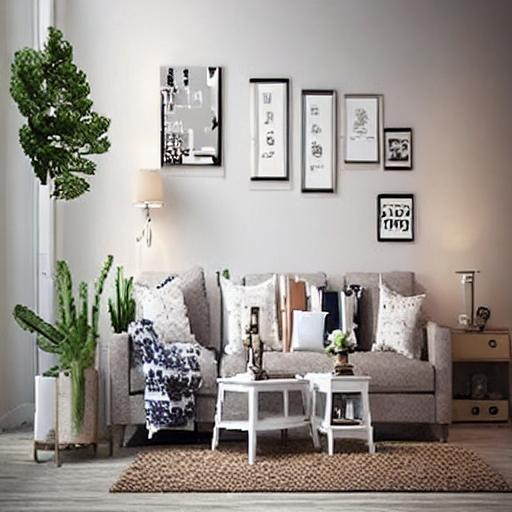

In [11]:
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image

base_model = "runwayml/stable-diffusion-v1-5"
lora_path = "/kaggle/working/output/respace_interior_lora_fast.safetensors"

# 2. Load the base model
print("Loading base model...")
pipe = StableDiffusionPipeline.from_pretrained(
    base_model, 
    torch_dtype=torch.float16, 
    safety_checker=None
).to("cuda")

# 3. Load your LoRA weights
print("Applying LoRA...")
pipe.load_lora_weights(lora_path)

# 4. Generate!
# PROMPT: Always start with your trigger word 'intdesign'
prompt = "intdesign, a photorealistic shot of a lounge designed for a cozy family atmosphere. The aesthetic is defined by modern white and a neutral color palette under warm indoor lighting, cinematic, 8k"

print("Generating image...")
image = pipe(
    prompt, 
    negative_prompt=negative_prompt,
    num_inference_steps=30, 
    guidance_scale=7.5
).images[0]

# 5. Display
display(image)
image.save("inference_test.png")

Generating image...


  0%|          | 0/30 [00:00<?, ?it/s]

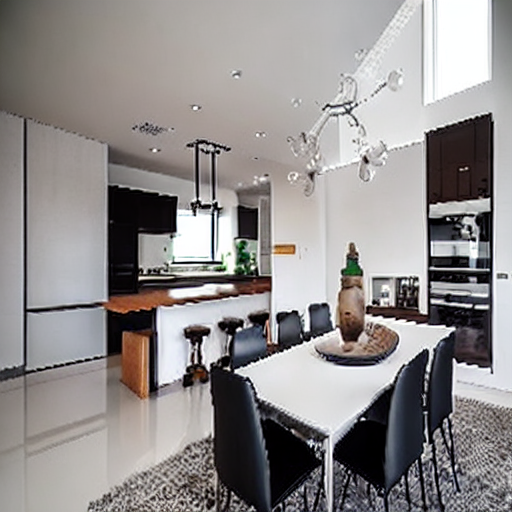

In [15]:
prompt = "Atmospheric Dining Room with Natural Daylight. This Casual Family oriented room uses Neutral colors and Modern White tones."

print("Generating image...")
image = pipe(
    prompt, 
    negative_prompt=negative_prompt,
    num_inference_steps=30, 
    guidance_scale=7.5
).images[0]

# 5. Display
display(image)
image.save("inference_test.png")

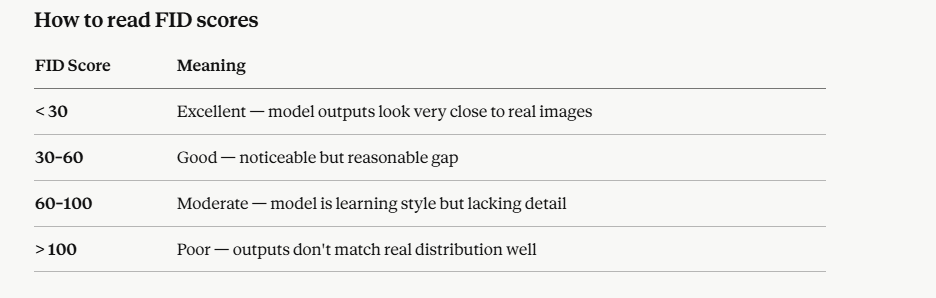